## Bijdrage Raoul Buffels — DeepLearningTeam10

Deze Citi Bike-uitwerking is aangeleverd als de bijdrage van **Raoul Buffels**. Teamleden: Jorre Van Dyck, Milan Wouters, Raoul Buffels en Andrew Noeyens. De concrete menselijke taakverdeling moet het team zelf aanvullen. **AI-gebruik:** Codex hielp met implementatie, uitleg, tests, uitvoering en verpakking.

De codecellen zijn uitgevoerd in de oorspronkelijke lokale `Citybike_full`-omgeving op 9 oktober 2026. Deze export behoudt die echte uitvoer; alleen deze Markdown-cel is toegevoegd. Lokale paden, timings en fingerprints in de rapporten beschrijven de oorspronkelijke uitvoering. Start voor heruitvoering vanuit `RaoulBuffels` of de map `notebooks` met de bijbehorende Python 3.11-omgeving. AWS is een afzonderlijke latere taak.

# 07 — Definitieve modelvergelijking en eindtest

Bijdragen: door team in te vullen. De modelkeuze lag vóór opening van de eindtest vast. Dit notebook toont bestaande evaluatie-uitvoer en voert geen nieuwe tuning uit.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Markdown
locations = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'Citybike_full']
ROOT = next((p for p in locations if (p / 'citibike').exists()), None)
if ROOT is None: raise RuntimeError('Start dit notebook vanuit Citybike_full of notebooks.')
sys.path.insert(0, str(ROOT))
from citibike.config import REPORTS, DATA, MODELS
from citibike.datasets import manifest
from citibike.plots import show
def report(name):
    return json.loads((REPORTS / name).read_text(encoding='utf-8'))
def table(name):
    display(pd.read_csv(REPORTS / name, dtype={'start_station_id':'string','end_station_id':'string','station_id':'string'}))


In [2]:
show('comparison')
display(pd.DataFrame([report('model_selection.json')]).drop(columns=['parameters','modeling_code_version']))

<Figure size 1200x500 with 2 Axes>

De laagste validatie-RMSE is 1940.49 bij tuned_random_forest; de train-RMSE is 536.13, een verschil van 1404.36 ritten/uur. Een hogere validatiefout kan op overfit of veranderde omstandigheden wijzen. De vastgelegde selectieregel mag binnen 1% het eenvoudigere model kiezen. Een lage trainingsfout alleen rechtvaardigt geen modelkeuze.

,created_at,name,validation_metrics,baseline_validation_metrics,validation_RMSE_improvement_percent,window_years,features,contract,dataset_fingerprint,fold_fingerprint,prediction_code_fingerprint,selection_rule,training_seconds,test_seen
0,2026-10-09T11:46:34.182420+00:00,tuned_random_forest,"{'RMSE': 1940.4928799155434, 'MAE': 1114.47960...","{'RMSE': 2826.1649200028373, 'MAE': 1510.12773...",31.3383,None,"[hour_sin, hour_cos, weekday_sin, weekday_cos,...","{'target': 'hourly_demand', 'prediction_time':...",409eb1829fa0565f464bbd031cc4e17c8c64f7c9aae466...,59238f467d526664e56943f96d102928ede96e4e371fec...,54679b92f35b8e0a737539e7bc1422f9c4c56c9c93119c...,lowest validation RMSE; strictly less than 1% ...,4368.53026,False


,finished_at,rows,metrics,baseline_metrics,RMSE_improvement_percent,MSE_gain_week_bootstrap_ci95,ci_limitation,selected_model,test_period,fixed_model_rolling_observation,retuned_after_test,selection_fingerprint,model_sha256
0,2026-10-09T11:48:25.875501+00:00,1488,"{'RMSE': 1979.5071598723391, 'MAE': 1076.22584...","{'RMSE': 2608.7775064111906, 'MAE': 1453.52822...",24.121273,"[1161795.8570921829, 4198151.224649241]",Slechts circa negen weekblokken; onzekerheidsi...,tuned_random_forest,"[2026-07-01, 2026-08-31]",True,False,2c52dfeebfcc41e144bb8867dc90506e1da73640cb9c7e...,aea5c81d306facc1fadd8dd1888a08219d3afabda16a11...


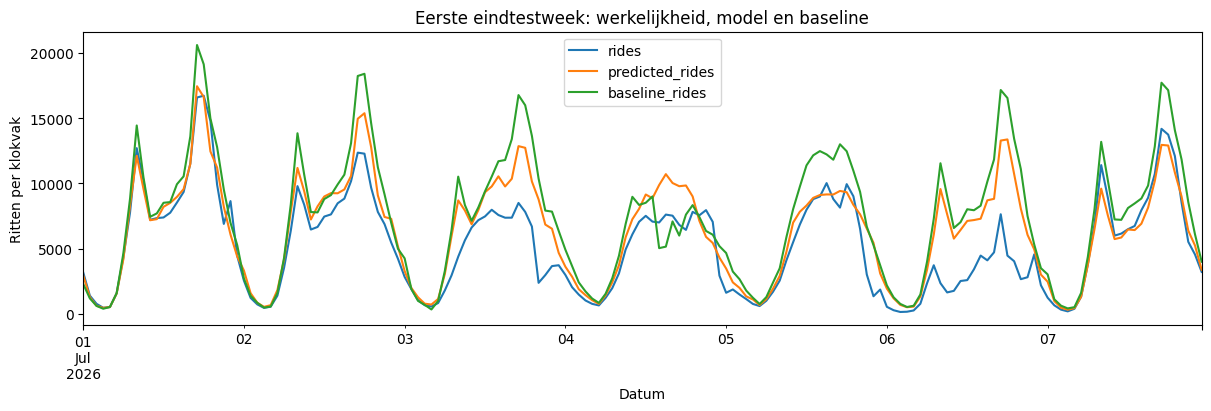

Over de volledige eindtest is de model-RMSE 1979.51, tegenover 2608.78 voor het vorige weekuur. Verbetering: 24.12%. Iedere dag gebruikt alleen eerder gemeten dagen.

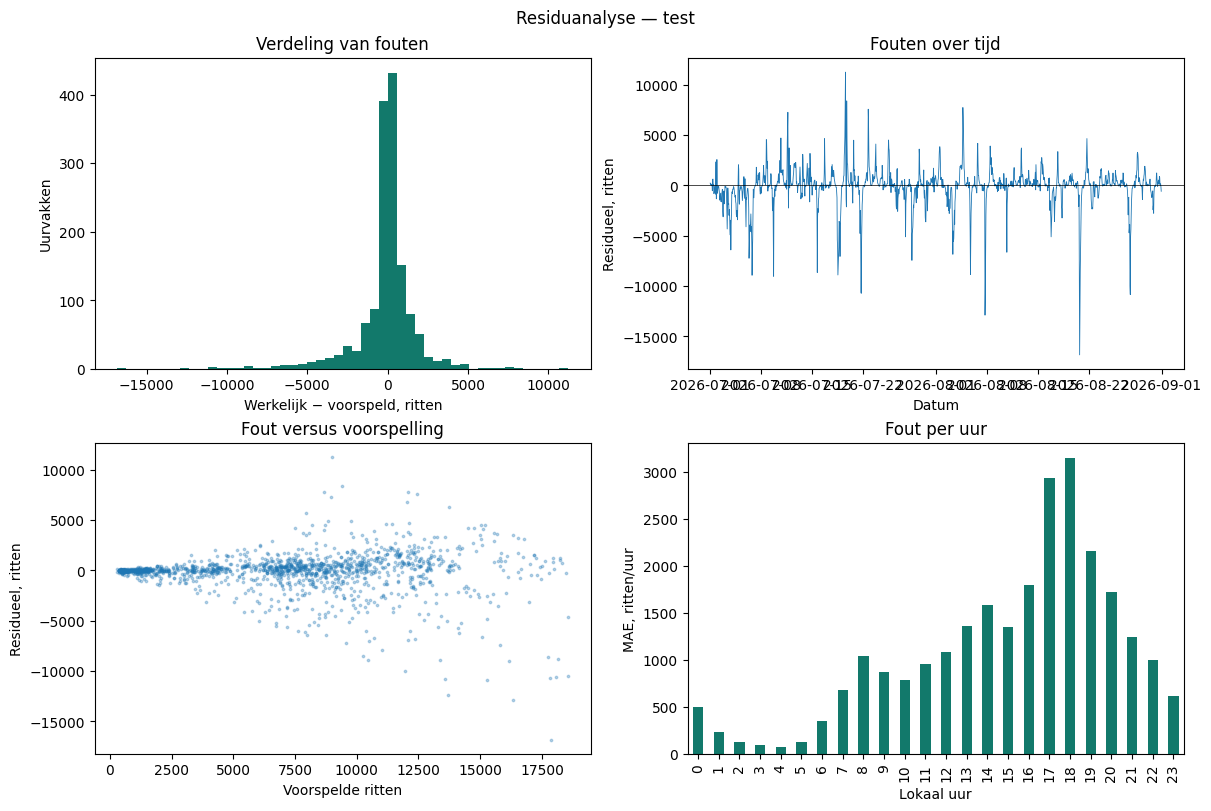

Gemiddelde bias: -127.60 ritten/uur. Het uur met de hoogste MAE is 18:00 (3147.24 ritten/uur). Overblijvende patronen wijzen op beperkingen. Eindtestdiagnostiek wordt uitsluitend achteraf beschreven en leidt niet tot nieuwe tuning onder dezelfde eindtestclaim.

In [3]:
display(pd.DataFrame([report('final_evaluation.json')]))
show('test_forecast')
show('residual_test')

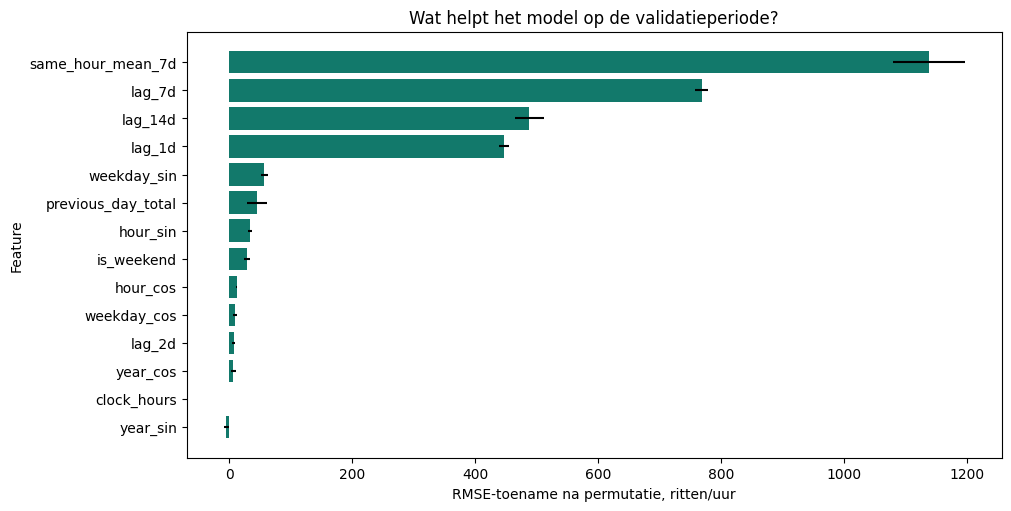

De sterkste gemeten permutation importance hoort bij same_hour_mean_7d: 1137.75 ritten/uur RMSE-toename. Afhankelijke features kunnen elkaars belang maskeren; onafhankelijke permutatie kan onrealistische combinaties maken. Dit toont geen causaliteit.

# Citi Bike-modelkaart

Gekozen model: **tuned_random_forest**. Het voorspelt geregistreerde NYC-vertrekken
per lokaal uurvak, voor één volledige kalenderdag vanaf 00:00 New York-tijd.
Veertien volledige voorafgaande dagen zijn nodig. Jersey City is uitgesloten.

| Metriek | Eindmodel | Vorig weekuur |
|---|---:|---:|
| RMSE, ritten/uur | 1979.51 | 2608.78 |
| MAE, ritten/uur | 1076.23 | 1453.53 |
| R² | 0.8280 | 0.7013 |

RMSE-verbetering: 24.12%. Eindtest juli–augustus 2026,
1488 klokvakken. Selectie en tuning gebruikten deze uitkomsten niet.
Het model blijft vast; eerder gemeten testdagen worden daarna historische invoer.
Het artefact is na de eindtest niet opnieuw getraind.

Dit is geregistreerd gebruik, geen onvervulde vraag of beschikbaarheid per station.
Weer, evenementen en capaciteit ontbreken. Feature importance toont geen causaliteit.
Historische schema's en gebruik veranderen; twee testmaanden dekken niet alle seizoenen.
Het weekbootstrapinterval bevat weinig blokken en geeft beperkte zekerheid.
De actuele maandarchieven leveren niet automatisch de recente historie voor morgen.
De backtest veronderstelt een externe bron met vóór 00:00 beschikbare uurtellingen.
Publicatie-, ingestie- en rekenlatentie zijn niet gemodelleerd. De prestaties gelden
onder dit invoercontract; een operationele tellingenfeed moet apart worden gerealiseerd.

Hertrain offline met de README-commando's. Modelbestanden staan lokaal en buiten Git.
Bronnen, code, packageversies, seeds, splits en fingerprints zijn vastgelegd.
AWS-training blijft open voor de volledige schoolopdracht.


In [4]:
show('importance')
display(Markdown((REPORTS/'MODEL_CARD.md').read_text(encoding='utf-8')))